# FSRS4Anki Optimizer Benchmark

[![open in colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-spaced-repetition/fsrs4anki/blob/benchmark/benchmark.ipynb)

In [1]:
# Here are some settings that you need to replace before running this optimizer.

filename = "./collection-2022-09-18@13-21-58.colpkg"
# If you upload deck file, replace it with your deck filename. E.g., ALL__Learning.apkg
# If you upload collection file, replace it with your colpgk filename. E.g., collection-2022-09-18@13-21-58.colpkg

# Replace it with your timezone. I'm in China, so I use Asia/Shanghai.
# You can find your timezone here: https://gist.github.com/heyalexej/8bf688fd67d7199be4a1682b3eec7568
timezone = 'Asia/Shanghai'

# Replace it with your Anki's setting in Preferences -> Scheduling.
next_day_starts_at = 4

# Replace it if you don't want the optimizer to use the review logs before a specific date.
revlog_start_date = "2006-10-05"

# Set it to True if you don't want the optimizer to use the review logs from suspended cards.
filter_out_suspended_cards = False

In [2]:
import zipfile
import sqlite3
import time
import pandas as pd
import numpy as np
import os
import math
from typing import List, Optional
from datetime import timedelta, datetime
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from torch import nn
from torch import Tensor
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_squared_error, r2_score
from itertools import accumulate
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
tqdm.pandas()

In [3]:
"""Step 1"""
# Extract the collection file or deck file to get the .anki21 database.
with zipfile.ZipFile(f'{filename}', 'r') as zip_ref:
    zip_ref.extractall('./')
    print("Deck file extracted successfully!")

"""Step 2"""
if os.path.isfile("collection.anki21b"):
    os.remove("collection.anki21b")
    raise Exception(
        "Please export the file with `support older Anki versions` if you use the latest version of Anki.")
elif os.path.isfile("collection.anki21"):
    con = sqlite3.connect("collection.anki21")
elif os.path.isfile("collection.anki2"):
    con = sqlite3.connect("collection.anki2")
else:
    raise Exception("Collection not exist!")
cur = con.cursor()
res = cur.execute(f"""
SELECT *
FROM revlog
WHERE cid IN (
    SELECT id
    FROM cards
    WHERE queue != 0
    {"AND queue != -1" if filter_out_suspended_cards else ""}
)
"""
)
revlog = res.fetchall()
if len(revlog) == 0:
    raise Exception("No review log found!")
df = pd.DataFrame(revlog)
df.columns = ['id', 'cid', 'usn', 'r', 'ivl', 'last_ivl', 'factor', 'time', 'type']
df = df[(df['cid'] <= time.time() * 1000) &
        (df['id'] <= time.time() * 1000)].copy()

df_set_due_date = df[(df['type'] == 4) & (df['ivl'] > 0)]
df.drop(df_set_due_date.index, inplace=True)

df['create_date'] = pd.to_datetime(df['cid'] // 1000, unit='s')
df['create_date'] = df['create_date'].dt.tz_localize('UTC').dt.tz_convert(timezone)
df.drop(df[df['create_date'].dt.year < 2006].index, inplace=True)
df['review_date'] = pd.to_datetime(df['id'] // 1000, unit='s')
df['review_date'] = df['review_date'].dt.tz_localize('UTC').dt.tz_convert(timezone)
df.drop(df[df['review_date'].dt.year < 2006].index, inplace=True)
df.sort_values(by=['cid', 'id'], inplace=True, ignore_index=True)

df['is_learn_start'] = (df['type'] == 0) & (df['type'].shift() != 0)
df['sequence_group'] = df['is_learn_start'].cumsum()
last_learn_start = df[df['is_learn_start']].groupby('cid')['sequence_group'].last()
df['last_learn_start'] = df['cid'].map(last_learn_start).fillna(0).astype(int)
df['mask'] = df['last_learn_start'] <= df['sequence_group']
df = df[df['mask'] == True].copy()
df.drop(columns=['is_learn_start', 'sequence_group', 'last_learn_start', 'mask'], inplace=True)
df = df[(df['type'] != 4)].copy()

type_sequence = np.array(df['type'])
time_sequence = np.array(df['time'])
df.to_csv("revlog.csv", index=False)
print("revlog.csv saved.")

df = df[(df['type'] != 3) | (df['factor'] != 0)].copy()
df['real_days'] = df['review_date'] - timedelta(hours=int(next_day_starts_at))
df['real_days'] = pd.DatetimeIndex(df['real_days'].dt.floor('D', ambiguous='infer', nonexistent='shift_forward')).to_julian_date()
df.drop_duplicates(['cid', 'real_days'], keep='first', inplace=True)
df['delta_t'] = df.real_days.diff()
df.dropna(inplace=True)
df['i'] = df.groupby('cid').cumcount() + 1
df.loc[df['i'] == 1, 'delta_t'] = 0
df = df.groupby('cid').filter(lambda group: group['type'].iloc[0] == 0)
df['prev_type'] = df.groupby('cid')['type'].shift(1).fillna(0).astype(int)
df['helper'] = ((df['type'] == 0) & ((df['prev_type'] == 1) | (df['prev_type'] == 2)) & (df['i'] > 1)).astype(int)
df['helper'] = df.groupby('cid')['helper'].cumsum()
df = df[df['helper'] == 0]
del df['prev_type']
del df['helper']

def cum_concat(x):
    return list(accumulate(x))

t_history = df.groupby('cid', group_keys=False)['delta_t'].apply(lambda x: cum_concat([[int(i)] for i in x]))
df['t_history']=[','.join(map(str, item[:-1])) for sublist in t_history for item in sublist]
r_history = df.groupby('cid', group_keys=False)['r'].apply(lambda x: cum_concat([[i] for i in x]))
df['r_history']=[','.join(map(str, item[:-1])) for sublist in r_history for item in sublist]
df = df.groupby('cid').filter(lambda group: group['id'].min() > time.mktime(datetime.strptime(revlog_start_date, "%Y-%m-%d").timetuple()) * 1000)
df['y'] = df['r'].map(lambda x: {1: 0, 2: 1, 3: 1, 4: 1}[x])
df.to_csv('revlog_history.tsv', sep="\t", index=False)
print("Trainset saved.")

df['retention'] = df.groupby(by=['r_history', 'delta_t'], group_keys=False)['y'].transform('mean')
df['total_cnt'] = df.groupby(by=['r_history', 'delta_t'], group_keys=False)['id'].transform('count')
print("Retention calculated.")

df = df.drop(columns=['id', 'cid', 'usn', 'ivl', 'last_ivl', 'factor', 'time', 'type', 'create_date', 'review_date', 'real_days', 'r', 't_history', 'y'])
df.drop_duplicates(inplace=True)
df['retention'] = df['retention'].map(lambda x: max(min(0.99, x), 0.01))

def cal_stability(group: pd.DataFrame) -> pd.DataFrame:
    group_cnt = sum(group['total_cnt'])
    if group_cnt < 10:
        return pd.DataFrame()
    group['group_cnt'] = group_cnt
    if group['i'].values[0] > 1:
        r_ivl_cnt = sum(group['delta_t'] * group['retention'].map(np.log) * pow(group['total_cnt'], 2))
        ivl_ivl_cnt = sum(group['delta_t'].map(lambda x: x ** 2) * pow(group['total_cnt'], 2))
        group['stability'] = round(np.log(0.9) / (r_ivl_cnt / ivl_ivl_cnt), 1)
    else:
        group['stability'] = 0.0
    group['avg_retention'] = round(sum(group['retention'] * pow(group['total_cnt'], 2)) / sum(pow(group['total_cnt'], 2)), 3)
    group['avg_interval'] = round(sum(group['delta_t'] * pow(group['total_cnt'], 2)) / sum(pow(group['total_cnt'], 2)), 1)
    del group['total_cnt']
    del group['retention']
    del group['delta_t']
    return group

df = df.groupby(by=['r_history'], group_keys=False).progress_apply(cal_stability)
print("Stability calculated.")
df.reset_index(drop = True, inplace = True)
df.drop_duplicates(inplace=True)
df.sort_values(by=['r_history'], inplace=True, ignore_index=True)

if df.shape[0] > 0:
    for idx in tqdm(df.index, desc="analysis"):
        item = df.loc[idx]
        index = df[(df['i'] == item['i'] + 1) & (df['r_history'].str.startswith(item['r_history']))].index
        df.loc[index, 'last_stability'] = item['stability']
    df['factor'] = round(df['stability'] / df['last_stability'], 2)
    df = df[(df['i'] >= 2) & (df['group_cnt'] >= 100)].copy()
    df['last_recall'] = df['r_history'].map(lambda x: x[-1])
    df = df[df.groupby(['i', 'r_history'], group_keys=False)['group_cnt'].transform(max) == df['group_cnt']]
    df.to_csv('./stability_for_analysis.tsv', sep='\t', index=None)
    print("Analysis saved!")
    caption = "1:again, 2:hard, 3:good, 4:easy\n"
    analysis = df[df['r_history'].str.contains(r'^[1-4][^124]*$', regex=True)][['r_history', 'avg_interval', 'avg_retention', 'stability', 'factor', 'group_cnt']].to_string(index=False)
    print(caption + analysis)

Deck file extracted successfully!
revlog.csv saved.
Trainset saved.
Retention calculated.


  0%|          | 0/26286 [00:00<?, ?it/s]

Stability calculated.


analysis:   0%|          | 0/489 [00:00<?, ?it/s]

Analysis saved!
1:again, 2:hard, 3:good, 4:easy
      r_history  avg_interval  avg_retention  stability  factor  group_cnt
              1           1.1          0.892        1.0     inf       2063
            1,3           3.1          0.920        4.0    4.00       1600
          1,3,3           7.1          0.910        7.9    1.98       1320
        1,3,3,3          16.6          0.862       10.8    1.37        986
      1,3,3,3,3          36.5          0.840       22.3    2.06        659
    1,3,3,3,3,3          77.0          0.861       36.4    1.63        358
  1,3,3,3,3,3,3         117.9          0.906       38.5    1.06        177
              2           1.0          0.902        1.1     inf        240
            2,3           3.5          0.946        8.2    7.45        201
          2,3,3          11.4          0.890        7.6    0.93        162
              3           1.1          0.977        5.0     inf       4669
            3,3           3.3          0.967       1

Weighted fit parameters: [1.25162861]
Number of reviews: 2063
RMSE: 0.0381


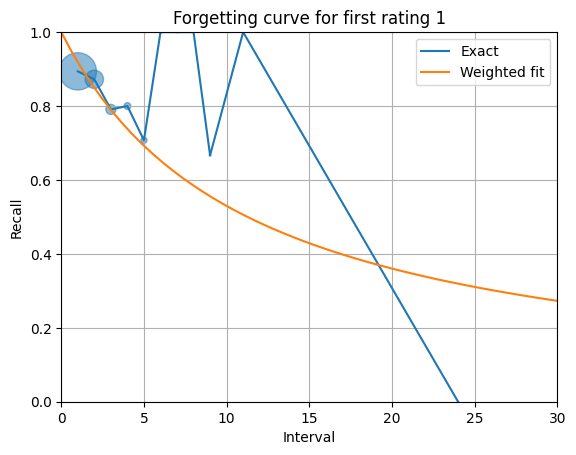

Weighted fit parameters: [1.71948624]
Number of reviews: 240
RMSE: 0.0599


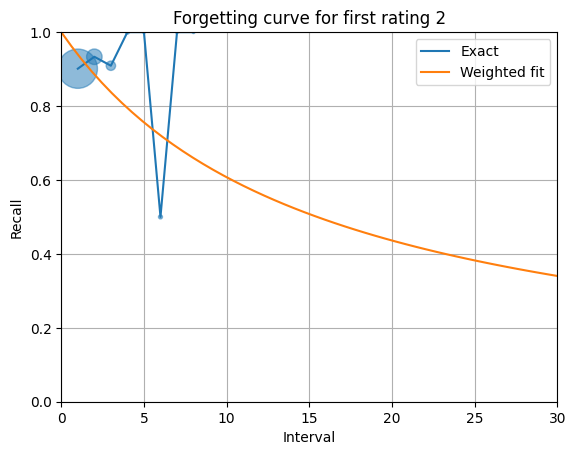

Weighted fit parameters: [8.75085746]
Number of reviews: 4669
RMSE: 0.0204


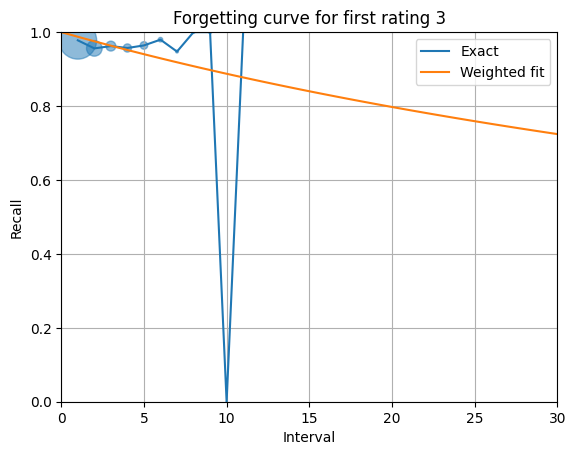

Weighted fit parameters: [16.52846133]
Number of reviews: 2789
RMSE: 0.0160


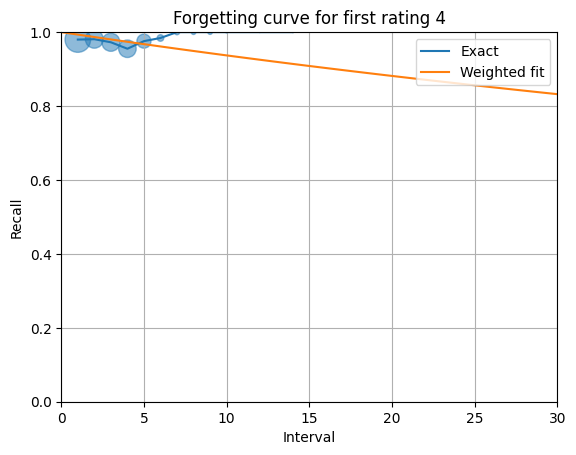

{1: 1.2516286139441613, 2: 1.7194862432507476, 3: 8.750857456400256, 4: 16.52846132731462}
Weighted fit parameters: [0.03758393 0.6949553  0.        ]
Fit stability: [ 2.08035641  4.1682427   8.35157242 16.73337346]
RMSE: 0.6171


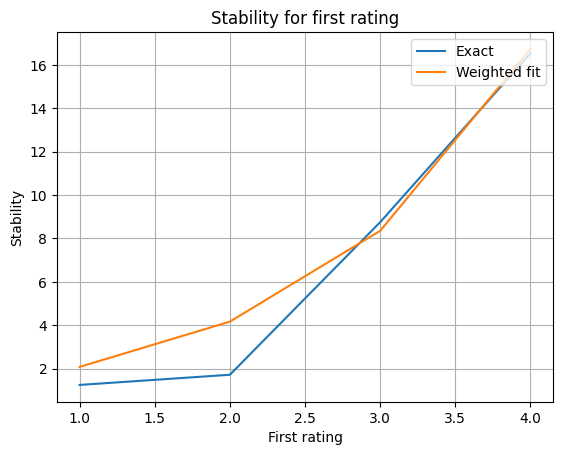

{1: 1.25, 2: 1.72, 3: 8.75, 4: 16.53}


In [4]:
from scipy.optimize import curve_fit

dataset = pd.read_csv("./revlog_history.tsv", sep='\t', index_col=None, dtype={'r_history': str ,'t_history': str} )
dataset = dataset[(dataset['i'] > 1) & (dataset['delta_t'] > 0) & (dataset['t_history'].str.count(',0') == 0)]
dataset['y'] = dataset['r'].map({1: 0, 2: 1, 3: 1, 4: 1})
S0_dataset = dataset[dataset['i'] == 2]
S0_dataset_group = S0_dataset.groupby(by=['r_history', 'delta_t'], group_keys=False).agg({'y': ['mean', 'count']}).reset_index()

# we want to find the optimal S
def power_curve(delta_t, S):
    return (1 + delta_t / (9 * S)) ** -1
# def exp_curve(delta_t, S):
#     return np.exp(np.log(0.9) * delta_t / S)

rating_stability = {}
rating_count = {}
reviews_in_collection = len(dataset)

for first_rating in ("1", "2", "3", "4"):
    group = S0_dataset_group[S0_dataset_group['r_history'] == first_rating]
    if group.empty:
        continue
    delta_t = group['delta_t']
    recall = group['y']['mean']
    count = group['y']['count']
    if sum(count) < 100:
        continue
    params, covs = curve_fit(power_curve, delta_t, recall, sigma=1/np.sqrt(count), bounds=((0.1), (3650)))
    rating_stability[int(first_rating)] = params[0]
    rating_count[int(first_rating)] = sum(count)
    print('Weighted fit parameters:', params)
    print('Number of reviews:', sum(count))
    predict_recall = power_curve(delta_t, *params)
    print(f'RMSE: {mean_squared_error(recall, predict_recall, sample_weight=count, squared=False):.4f}')

    plt.plot(delta_t, recall, label='Exact')
    plt.plot(np.linspace(0, 30), power_curve(np.linspace(0, 30), *params), label='Weighted fit')
    count_percent = np.array([x/sum(count) for x in count])
    plt.scatter(delta_t, recall, s=count_percent * 1000, alpha=0.5)
    plt.legend(loc='upper right', fancybox=True, shadow=False)
    plt.grid(True)
    plt.ylim(0, 1)
    plt.xlim(0, 30)
    plt.xlabel('Interval')
    plt.ylabel('Recall')
    plt.title('Forgetting curve for first rating ' + first_rating)
    plt.show()

print(rating_stability)

def S0_rating_curve(rating, a, b, c):
    return np.exp(a + b * rating) + c

params, covs = curve_fit(S0_rating_curve, list(rating_stability.keys()), list(rating_stability.values()), sigma=1/np.sqrt(list(rating_count.values())), method='dogbox', bounds=((-15, 0.03, 0), (15, 7, 30)))
print('Weighted fit parameters:', params)
predict_stability = S0_rating_curve(np.array(list(rating_stability.keys())), *params)
print("Fit stability:", predict_stability)
print(f'RMSE: {mean_squared_error(list(rating_stability.values()), predict_stability, sample_weight=list(rating_count.values()), squared=False):.4f}')
plt.plot(list(rating_stability.keys()), list(rating_stability.values()), label='Exact')
plt.plot(list(rating_stability.keys()), predict_stability, label='Weighted fit')
plt.legend(loc='upper right', fancybox=True, shadow=False)
plt.grid(True)
plt.xlabel('First rating')
plt.ylabel('Stability')
plt.title('Stability for first rating')
plt.show()

for rating in (1, 2, 3, 4):
    again_extrap = max(min(S0_rating_curve(1, *params), 3650), 0.1)
    # if there isn't enough data to calculate the value for "Again" exactly
    if 1 not in rating_stability:
        # then check if there exists an exact value for "Hard"
        if 2 in rating_stability:
            # if it exists, then check whether the extrapolation breaks monotonicity
            # Again > Hard is possible, but we should allow it only for exact values, otherwise we should assume monotonicity
            if again_extrap > rating_stability[2]:
                # if it does, then replace the missing "Again" value with the exact "Hard" value
                rating_stability[1] = rating_stability[2]
            else:
                # if it doesn't break monotonicity, then use the extrapolated value
                rating_stability[1] = again_extrap
        # if an exact value for "Hard" doesn't exist, then just use the extrapolation, there's nothing else we can do
        else:
            rating_stability[1] = again_extrap
    elif rating not in rating_stability:
        rating_stability[rating] = max(min(S0_rating_curve(rating, *params), 3650), 0.1)

rating_stability = {k: round(v, 2) for k, v in sorted(rating_stability.items(), key=lambda item: item[0])}

print(rating_stability)

In [5]:
class FSRS3WeightClipper:
    def __init__(self, frequency: int=1):
        self.frequency = frequency

    def __call__(self, module):
        if hasattr(module, 'w'):
            w = module.w.data
            w[0] = w[0].clamp(0.1, 10)
            w[1] = w[1].clamp(0.1, 5)
            w[2] = w[2].clamp(1, 10)
            w[3] = w[3].clamp(-5, -0.1)
            w[4] = w[4].clamp(-5, -0.1)
            w[5] = w[5].clamp(0.05, 0.5)
            w[6] = w[6].clamp(0, 2)
            w[7] = w[7].clamp(-0.8, -0.15)
            w[8] = w[8].clamp(0.01, 1.5)
            w[9] = w[9].clamp(0.5, 5)
            w[10] = w[10].clamp(-2, -0.01)
            w[11] = w[11].clamp(0.01, 0.9)
            w[12] = w[12].clamp(0.01, 2)
            module.w.data = w

class FSRS3(nn.Module):
    init_w = [1, 1, 5, -0.5, -0.5, 0.2, 1.4, -0.2, 0.8, 2, -0.2, 0.2, 1]
    clipper = FSRS3WeightClipper()
    def __init__(self, w: List[float] = init_w):
        super(FSRS3, self).__init__()
        self.w = nn.Parameter(torch.tensor(w, dtype=torch.float32))

    def forgetting_curve(self, t, s):
        return 0.9 ** (t / s)

    def stability_after_success(self, state: Tensor, new_d: Tensor, r: Tensor) -> Tensor:
        new_s = state[:,0] * (1 + torch.exp(self.w[6]) *
                        (11 - new_d) *
                        torch.pow(state[:,0], self.w[7]) *
                        (torch.exp((1 - r) * self.w[8]) - 1))
        return new_s

    def stability_after_failure(self, state: Tensor, new_d: Tensor, r: Tensor) -> Tensor:
        new_s = self.w[9] * torch.pow(new_d, self.w[10]) * torch.pow(
            state[:,0], self.w[11]) * torch.exp((1 - r) * self.w[12])
        return new_s

    def step(self, X: Tensor, state: Tensor) -> Tensor:
        '''
        :param X: shape[batch_size, 2], X[:,0] is elapsed time, X[:,1] is rating
        :param state: shape[batch_size, 2], state[:,0] is stability, state[:,1] is difficulty
        :return state:
        '''
        if torch.equal(state, torch.zeros_like(state)):
            # first learn, init memory states
            new_s = self.w[0] + self.w[1] * (X[:,1] - 1)
            new_d = self.w[2] + self.w[3] * (X[:,1] - 3)
            new_d = new_d.clamp(1, 10)
        else:
            r = self.forgetting_curve(X[:,0], state[:,0])
            new_d = state[:,1] + self.w[4] * (X[:,1] - 3)
            new_d = self.mean_reversion(self.w[2], new_d)
            new_d = new_d.clamp(1, 10)
            condition = X[:,1] > 1
            new_s = torch.where(condition, self.stability_after_success(state, new_d, r), self.stability_after_failure(state, new_d, r))
        new_s = new_s.clamp(0.1, 36500)
        return torch.stack([new_s, new_d], dim=1)

    def forward(self, inputs: Tensor, state: Optional[Tensor]=None) -> Tensor:
        '''
        :param inputs: shape[seq_len, batch_size, 2]
        '''
        if state is None:
            state = torch.zeros((inputs.shape[1], 2))
        outputs = []
        for X in inputs:
            state = self.step(X, state)
            outputs.append(state)
        return torch.stack(outputs), state

    def mean_reversion(self, init: Tensor, current: Tensor) -> Tensor:
        return self.w[5] * init + (1-self.w[5]) * current
    


class FSRS4WeightClipper:
    def __init__(self, frequency: int=1):
        self.frequency = frequency

    def __call__(self, module):
        if hasattr(module, 'w'):
            w = module.w.data
            w[0] = w[0].clamp(0.1, 10)
            w[1] = w[1].clamp(0.1, 5)
            w[2] = w[2].clamp(1, 10)
            w[3] = w[3].clamp(-5, -0.1)
            w[4] = w[4].clamp(-5, -0.1)
            w[5] = w[5].clamp(0, 0.5)
            w[6] = w[6].clamp(0, 2)
            w[7] = w[7].clamp(-0.8, -0.1)
            w[8] = w[8].clamp(0.01, 1.5)
            w[9] = w[9].clamp(0.5, 5)
            w[10] = w[10].clamp(-2, -0.01)
            w[11] = w[11].clamp(0.01, 0.9)
            w[12] = w[12].clamp(0.01, 2)
            w[13] = w[13].clamp(0, 1)
            w[14] = w[14].clamp(1, 10)
            module.w.data = w


class FSRS4(nn.Module):
    init_w = [1, 1, 5, -0.5, -0.5, 0.2, 1.4, -0.2, 0.8, 2, -0.2, 0.2, 1, 0.5, 2]
    clipper = FSRS4WeightClipper()
    def __init__(self, w: List[float] = init_w):
        super(FSRS4, self).__init__()
        self.w = nn.Parameter(torch.tensor(w, dtype=torch.float32))
        self.s0 = torch.zeros(4)
        for i in range(4):
            if i+1 in rating_stability:
                self.s0[i] = rating_stability[i+1]

    def forgetting_curve(self, t, s):
        return (1 + t / (9 * s)) ** -1

    def stability_after_success(self, state: Tensor, new_d: Tensor, r: Tensor, rating: Tensor) -> Tensor:
        hard_bonus = torch.where(rating == 2, self.w[13], 1)
        easy_bonus = torch.where(rating == 4, self.w[14], 1)
        new_s = state[:,0] * (1 + torch.exp(self.w[6]) *
                        (11 - new_d) *
                        torch.pow(state[:,0], self.w[7]) *
                        (torch.exp((1 - r) * self.w[8]) - 1) * hard_bonus * easy_bonus)
        return new_s

    def stability_after_failure(self, state: Tensor, new_d: Tensor, r: Tensor) -> Tensor:
        new_s = self.w[9] * \
                torch.pow(new_d, self.w[10]) * \
                (torch.pow(state[:,0] + 1, self.w[11]) - 1) * \
                torch.exp((1 - r) * self.w[12])
        return new_s

    def step(self, X: Tensor, state: Tensor) -> Tensor:
        '''
        :param X: shape[batch_size, 2], X[:,0] is elapsed time, X[:,1] is rating
        :param state: shape[batch_size, 2], state[:,0] is stability, state[:,1] is difficulty
        :return state:
        '''
        if torch.equal(state, torch.zeros_like(state)):
            keys = torch.tensor([1, 2, 3, 4])
            keys = keys.view(1, -1).expand(X[:,1].long().size(0), -1)
            index = (X[:,1].long().unsqueeze(1) == keys).nonzero(as_tuple=True)
            # first learn, init memory states
            new_s = self.s0[index[1]]
            new_d = self.w[2] + self.w[3] * (X[:,1] - 3)
            new_d = new_d.clamp(1, 10)
        else:
            r = self.forgetting_curve(X[:,0], state[:,0])
            new_d = state[:,1] + self.w[4] * (X[:,1] - 3)
            new_d = self.mean_reversion(self.w[2], new_d)
            new_d = new_d.clamp(1, 10)
            condition = X[:,1] > 1
            new_s = torch.where(condition, self.stability_after_success(state, new_d, r, X[:,1]), self.stability_after_failure(state, new_d, r))
        new_s = new_s.clamp(0.1, 36500)
        return torch.stack([new_s, new_d], dim=1)

    def forward(self, inputs: Tensor, state: Optional[Tensor]=None) -> Tensor:
        '''
        :param inputs: shape[seq_len, batch_size, 2]
        '''
        if state is None:
            state = torch.zeros((inputs.shape[1], 2))
        outputs = []
        for X in inputs:
            state = self.step(X, state)
            outputs.append(state)
        return torch.stack(outputs), state

    def mean_reversion(self, init: Tensor, current: Tensor) -> Tensor:
        return self.w[5] * init + (1-self.w[5]) * current

n_input=5
n_hidden=8
n_output=1
n_layers=1
network="LSTM"
class RNN(nn.Module):
    def __init__(self, state_dict=None):
        super().__init__()
        self.n_input = n_input
        self.n_hidden = n_hidden
        self.n_out = n_output
        self.n_layers = n_layers
        if network == 'GRU':
            self.rnn = nn.GRU(input_size=self.n_input, hidden_size=self.n_hidden, num_layers=self.n_layers)
        elif network == "LSTM":
            self.rnn = nn.LSTM(input_size=self.n_input, hidden_size=self.n_hidden, num_layers=self.n_layers)
        else:
            self.rnn = nn.RNN(input_size=self.n_input, hidden_size=self.n_hidden, num_layers=self.n_layers)

        self.fc = nn.Linear(self.n_hidden, self.n_out)

        if state_dict is not None:
            self.load_state_dict(state_dict)

    def forward(self, x, hx=None):
        x, h = self.rnn(x, hx=hx)
        output = torch.exp(self.fc(x))
        return output, h

    def full_connect(self, h):
        return self.fc(h)

    def forgetting_curve(self, t, s):
        return 0.9 ** (t / s)

def lineToTensor(line: str) -> Tensor:
    ivl = line[0].split(',')
    response = line[1].split(',')
    tensor = torch.zeros(len(response), 2)
    for li, response in enumerate(response):
        tensor[li][0] = int(ivl[li])
        tensor[li][1] = int(response)
    return tensor

def lineToTensorRNN(line):
    ivl = line[0].split(',')
    response = line[1].split(',')
    tensor = torch.zeros(len(response), 5, dtype=torch.float32)
    for li, response in enumerate(response):
        tensor[li][0] = int(ivl[li])
        tensor[li][int(response)] = 1
    return tensor

class RevlogDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame):
        if dataframe.empty:
            raise ValueError('Training data is inadequate.')
        self.x_train = pad_sequence(dataframe['tensor'].to_list(), batch_first=True, padding_value=0)
        self.t_train = torch.tensor(dataframe['delta_t'].values, dtype=torch.int)
        self.y_train = torch.tensor(dataframe['y'].values, dtype=torch.float)
        self.seq_len = torch.tensor(dataframe['tensor'].map(len).values, dtype=torch.long)

    def __getitem__(self, idx):
        return self.x_train[idx], self.t_train[idx], self.y_train[idx], self.seq_len[idx]

    def __len__(self):
        return len(self.y_train)

class RevlogSampler(Sampler[List[int]]):
    def __init__(self, data_source: RevlogDataset, batch_size: int):
        self.data_source = data_source
        self.batch_size = batch_size
        lengths = np.array(data_source.seq_len)
        indices = np.argsort(lengths)
        full_batches, remainder = divmod(indices.size, self.batch_size)
        if full_batches > 0:
            if remainder == 0:
                self.batch_indices = np.split(indices, full_batches)
            else:
                self.batch_indices = np.split(indices[:-remainder], full_batches)
        else:
            self.batch_indices = []
        if remainder > 0:
            self.batch_indices.append(indices[-remainder:])
        self.batch_nums = len(self.batch_indices)
        # seed = int(torch.empty((), dtype=torch.int64).random_().item())
        seed = 2023
        self.generator = torch.Generator()
        self.generator.manual_seed(seed)

    def __iter__(self):
        yield from (self.batch_indices[idx] for idx in torch.randperm(self.batch_nums, generator=self.generator).tolist())

    def __len__(self):
        return len(self.data_source)


def collate_fn(batch):
    sequences, delta_ts, labels, seq_lens = zip(*batch)
    sequences_packed = pack_padded_sequence(torch.stack(sequences, dim=1), lengths=torch.stack(seq_lens), batch_first=False, enforce_sorted=False)
    sequences_padded, length = pad_packed_sequence(sequences_packed, batch_first=False)
    sequences_padded = torch.as_tensor(sequences_padded)
    seq_lens = torch.as_tensor(length)
    delta_ts = torch.as_tensor(delta_ts)
    labels = torch.as_tensor(labels)
    return sequences_padded, delta_ts, labels, seq_lens

class Trainer:
    def __init__(self, MODEL: nn.Module, train_set: pd.DataFrame, test_set: pd.DataFrame, n_epoch: int=1, lr: float=1e-2, batch_size: int=256) -> None:
        self.model = MODEL
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.clipper = MODEL.clipper if not isinstance(MODEL, RNN) else None
        self.batch_size = batch_size
        self.build_dataset(train_set, test_set)
        self.n_epoch = n_epoch
        self.batch_nums = self.next_train_data_loader.batch_sampler.batch_nums
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=self.batch_nums * n_epoch)
        self.avg_train_losses = []
        self.avg_eval_losses = []
        self.loss_fn = nn.BCELoss(reduction='none')

    def build_dataset(self, train_set: pd.DataFrame, test_set: pd.DataFrame):
        pre_train_set = train_set[train_set['i'] == 2]
        self.pre_train_set = RevlogDataset(pre_train_set)
        sampler = RevlogSampler(self.pre_train_set, batch_size=self.batch_size)
        self.pre_train_data_loader = DataLoader(self.pre_train_set, batch_sampler=sampler, collate_fn=collate_fn)

        next_train_set = train_set[train_set['i'] > 2]
        self.next_train_set = RevlogDataset(next_train_set)
        sampler = RevlogSampler(self.next_train_set, batch_size=self.batch_size)
        self.next_train_data_loader = DataLoader(self.next_train_set, batch_sampler=sampler, collate_fn=collate_fn)

        self.train_set = RevlogDataset(train_set)
        sampler = RevlogSampler(self.train_set, batch_size=self.batch_size)
        self.train_data_loader = DataLoader(self.train_set, batch_sampler=sampler, collate_fn=collate_fn)

        self.test_set = RevlogDataset(test_set)
        sampler = RevlogSampler(self.test_set, batch_size=self.batch_size)
        self.test_data_loader = DataLoader(self.test_set, batch_sampler=sampler, collate_fn=collate_fn)
        print("dataset built")

    def train(self, verbose: bool=True):
        best_loss = np.inf

        if isinstance(self.model, RNN):
            epoch_len = len(self.train_data_loader)
            pbar = tqdm(desc="train", colour="red", total=epoch_len*self.n_epoch)
            print_len = max(self.batch_nums*self.n_epoch // 5, 1)
            for k in range(self.n_epoch):
                weighted_loss = self.eval()
                for i, batch in enumerate(self.train_data_loader):
                    self.model.train()
                    self.optimizer.zero_grad()
                    sequences, delta_ts, labels, seq_lens = batch
                    real_batch_size = seq_lens.shape[0]
                    outputs, _ = self.model(sequences)
                    stabilities = outputs[seq_lens-1, torch.arange(real_batch_size), 0]
                    retentions = self.model.forgetting_curve(delta_ts, stabilities)
                    loss = self.loss_fn(retentions, labels).sum()
                    loss.backward()
                    self.optimizer.step()
                    self.scheduler.step()
                    pbar.update(real_batch_size)
            return self.model.state_dict()

        if isinstance(self.model, FSRS3):
            for k in range(self.n_epoch):
                for i, batch in enumerate(self.pre_train_data_loader):
                    self.model.train()
                    self.optimizer.zero_grad()
                    sequences, delta_ts, labels, seq_lens = batch
                    real_batch_size = seq_lens.shape[0]
                    outputs, _ = self.model(sequences)
                    stabilities = outputs[seq_lens-1, torch.arange(real_batch_size), 0]
                    retentions = self.model.forgetting_curve(delta_ts, stabilities)
                    loss = self.loss_fn(retentions, labels).sum()
                    loss.backward()
                    self.optimizer.step()
                    self.model.apply(self.clipper)

        epoch_len = len(self.next_train_data_loader)
        pbar = tqdm(desc="train", colour="red", total=epoch_len*self.n_epoch)
        print_len = max(self.batch_nums*self.n_epoch // 10, 1)
        for k in range(self.n_epoch):
            weighted_loss, w = self.eval()
            if weighted_loss < best_loss:
                best_loss = weighted_loss
                best_w = w

            for i, batch in enumerate(self.next_train_data_loader):
                self.model.train()
                self.optimizer.zero_grad()
                sequences, delta_ts, labels, seq_lens = batch
                real_batch_size = seq_lens.shape[0]
                outputs, _ = self.model(sequences)
                stabilities = outputs[seq_lens-1, torch.arange(real_batch_size), 0]
                retentions = self.model.forgetting_curve(delta_ts, stabilities)
                loss = self.loss_fn(retentions, labels).sum()
                loss.backward()
                for param in self.model.parameters():
                    param.grad[:2] = torch.zeros(2)
                self.optimizer.step()
                self.scheduler.step()
                self.model.apply(self.clipper)
                pbar.update(real_batch_size)

                if verbose and (k * self.batch_nums + i + 1) % print_len == 0:
                    tqdm.write(f"iteration: {k * epoch_len + (i + 1) * self.batch_size}")
                    for name, param in self.model.named_parameters():
                        tqdm.write(f"{name}: {list(map(lambda x: round(float(x), 4),param))}")
        pbar.close()

        weighted_loss, w = self.eval()
        if weighted_loss < best_loss:
            best_loss = weighted_loss
            best_w = w

        return best_w

    def eval(self):
        self.model.eval()
        with torch.no_grad():
            sequences, delta_ts, labels, seq_lens = self.train_set.x_train, self.train_set.t_train, self.train_set.y_train, self.train_set.seq_len
            real_batch_size = seq_lens.shape[0]
            outputs, _ = self.model(sequences.transpose(0, 1))
            stabilities = outputs[seq_lens-1, torch.arange(real_batch_size), 0]
            retentions = self.model.forgetting_curve(delta_ts, stabilities)
            tran_loss = self.loss_fn(retentions, labels).mean()
            self.avg_train_losses.append(tran_loss)

            sequences, delta_ts, labels, seq_lens = self.test_set.x_train, self.test_set.t_train, self.test_set.y_train, self.test_set.seq_len
            real_batch_size = seq_lens.shape[0]
            outputs, _ = self.model(sequences.transpose(0, 1))
            stabilities = outputs[seq_lens-1, torch.arange(real_batch_size), 0]
            retentions = self.model.forgetting_curve(delta_ts, stabilities)
            test_loss = self.loss_fn(retentions, labels).mean()
            self.avg_eval_losses.append(test_loss)

            if isinstance(self.model, RNN):
                w = self.model.state_dict()
            else:
                w = list(map(lambda x: round(float(x), 4), dict(self.model.named_parameters())['w'].data))

            weighted_loss = (tran_loss * len(self.train_set) + test_loss * len(self.test_set)) / (len(self.train_set) + len(self.test_set))

            return weighted_loss, w

    def plot(self):
        fig = plt.figure()
        ax = fig.gca()
        ax.plot(self.avg_train_losses, label='train')
        ax.plot(self.avg_eval_losses, label='test')
        ax.set_xlabel('epoch')
        ax.set_ylabel('loss')
        ax.legend()
        return fig
    
class Collection:
    def __init__(self, MDOEL) -> None:
        self.model = MDOEL
        self.model.eval()

    def predict(self, t_history: str, r_history: str):
        with torch.no_grad():
            if isinstance(self.model, RNN):
                line_tensor = lineToTensorRNN(list(zip([t_history], [r_history]))[0]).unsqueeze(1)
            else:
                line_tensor = lineToTensor(list(zip([t_history], [r_history]))[0]).unsqueeze(1)
            output_t = self.model(line_tensor)
            return output_t[-1][0]

    def batch_predict(self, dataset):
        fast_dataset = RevlogDataset(dataset)
        with torch.no_grad():
            outputs, _ = self.model(fast_dataset.x_train.transpose(0, 1))
            if isinstance(self.model, RNN):
                stabilities = outputs[fast_dataset.seq_len-1, torch.arange(len(fast_dataset))].transpose(0, 1)[0]
            else:
                stabilities, _ = outputs[fast_dataset.seq_len-1, torch.arange(len(fast_dataset))].transpose(0, 1)
            return stabilities.tolist()
        
# code from https://github.com/papousek/duolingo-halflife-regression/blob/master/evaluation.py
def load_brier(predictions, real, bins=20):
    counts = np.zeros(bins)
    correct = np.zeros(bins)
    prediction = np.zeros(bins)
    for p, r in zip(predictions, real):
        bin = min(int(p * bins), bins - 1)
        counts[bin] += 1
        correct[bin] += r
        prediction[bin] += p
    np.seterr(invalid='ignore')
    prediction_means = prediction / counts
    prediction_means[np.isnan(prediction_means)] = ((np.arange(bins) + 0.5) / bins)[np.isnan(prediction_means)]
    correct_means = correct / counts
    correct_means[np.isnan(correct_means)] = 0
    size = len(predictions)
    answer_mean = sum(correct) / size
    return {
        "reliability": sum(counts * (correct_means - prediction_means) ** 2) / size,
        "resolution": sum(counts * (correct_means - answer_mean) ** 2) / size,
        "uncertainty": answer_mean * (1 - answer_mean),
        "detail": {
            "bin_count": bins,
            "bin_counts": list(counts),
            "bin_prediction_means": list(prediction_means),
            "bin_correct_means": list(correct_means),
        }
    }


def plot_brier(predictions, real, bins=20):
    brier = load_brier(predictions, real, bins=bins)
    bin_prediction_means = brier['detail']['bin_prediction_means']
    bin_correct_means = brier['detail']['bin_correct_means']
    bin_counts = brier['detail']['bin_counts']
    r2 = r2_score(bin_correct_means, bin_prediction_means, sample_weight=bin_counts)
    rmse = mean_squared_error(bin_correct_means, bin_prediction_means, sample_weight=bin_counts, squared=False)
    print(f"R-squared: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    ax = plt.gca()
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    plt.grid(True)
    fit_wls = sm.WLS(bin_correct_means, sm.add_constant(bin_prediction_means), weights=bin_counts).fit()
    print(fit_wls.params)
    y_regression = [fit_wls.params[0] + fit_wls.params[1]*x for x in bin_prediction_means]
    plt.plot(bin_prediction_means, y_regression, label='Weighted Least Squares Regression', color="green")
    plt.plot(bin_prediction_means, bin_correct_means, label='Actual Calibration', color="#1f77b4")
    plt.plot((0, 1), (0, 1), label='Perfect Calibration', color="#ff7f0e")
    bin_count = brier['detail']['bin_count']
    counts = np.array(bin_counts)
    bins = (np.arange(bin_count) + 0.5) / bin_count
    plt.legend(loc='upper center')
    plt.xlabel('Predicted R')
    plt.ylabel('Actual R')
    plt.twinx()
    plt.ylabel('Number of reviews')
    plt.bar(bins, counts, width=(0.8 / bin_count), ec='k', lw=.2, alpha=0.5, label='Number of reviews')
    plt.legend(loc='lower center')


  0%|          | 0/88151 [00:00<?, ?it/s]

Tensorized!
dataset built


train:   0%|          | 0/440755 [00:00<?, ?it/s]


Training finished!
Total parameters: 489
loss before: 4.1327, loss after: 0.3044, improvement: 3.8283
R-squared: 0.9249
RMSE: 0.0214
[0.123219   0.86463599]


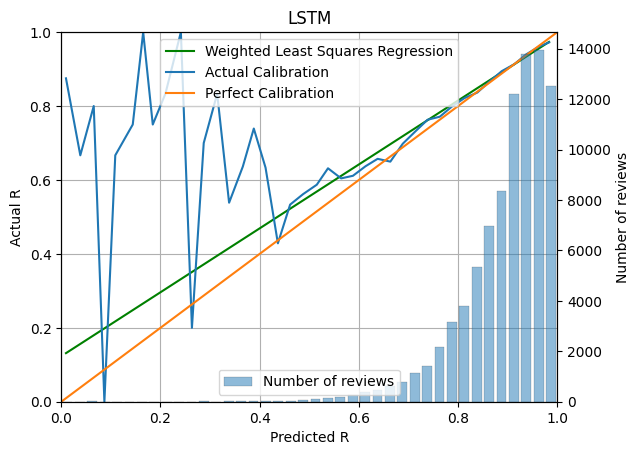


Last rating: 1
R-squared: 0.0737
RMSE: 0.0480
[0.39677744 0.54306289]

Last rating: 2
R-squared: 0.5851
RMSE: 0.0539
[0.27476423 0.67108817]

Last rating: 3
R-squared: 0.9478
RMSE: 0.0186
[0.06864785 0.92933797]

Last rating: 4
R-squared: 0.4984
RMSE: 0.0261
[0.27626673 0.71293659]


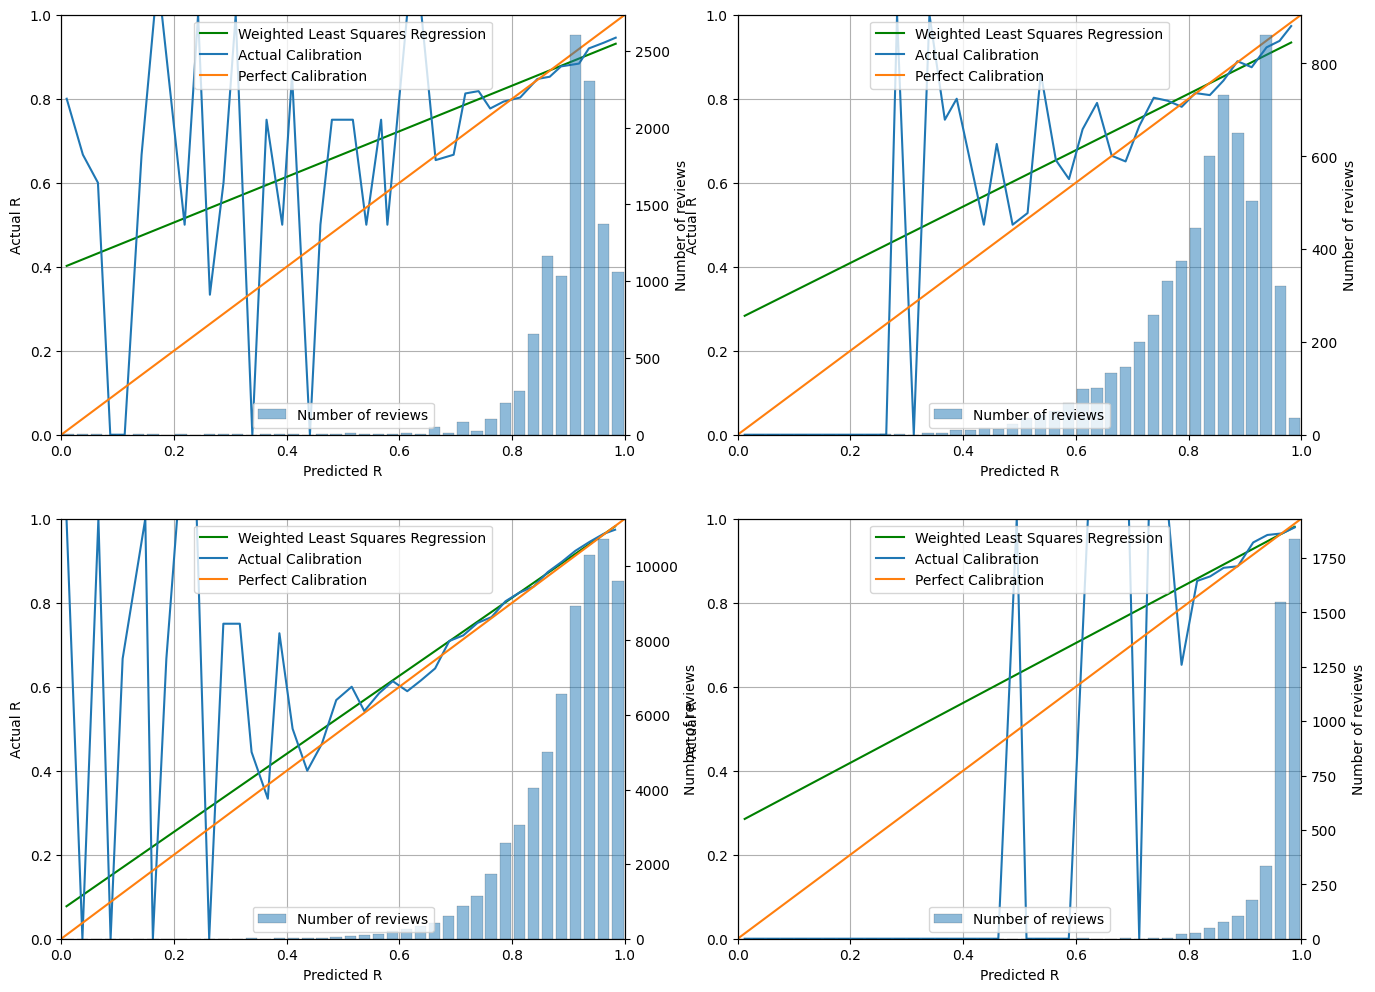

In [6]:
lr: float = 4e-2
n_epoch: int = 5
n_splits: int = 1
batch_size: int = 512
verbose: bool = False

model = RNN

dataset = pd.read_csv("./revlog_history.tsv", sep='\t', index_col=None, dtype={'r_history': str ,'t_history': str} )
dataset = dataset[(dataset['i'] > 1) & (dataset['delta_t'] > 0) & (dataset['t_history'].str.count(',0') == 0)]
if dataset.empty:
    raise ValueError('Training data is inadequate.')

if model == RNN:
    dataset['tensor'] = dataset.progress_apply(lambda x: lineToTensorRNN(list(zip([x['t_history']], [x['r_history']]))[0]), axis=1)
else:
    dataset['tensor'] = dataset.progress_apply(lambda x: lineToTensor(list(zip([x['t_history']], [x['r_history']]))[0]), axis=1)
dataset['group'] = dataset['r_history'] + dataset['t_history']
print("Tensorized!")

lstm_w = []
plots = []
if n_splits > 1:
    sgkf = StratifiedGroupKFold(n_splits=n_splits)
    for train_index, test_index in sgkf.split(dataset, dataset['i'], dataset['group']):
        print("TRAIN:", len(train_index), "TEST:",  len(test_index))
        train_set = dataset.iloc[train_index].copy()
        test_set = dataset.iloc[test_index].copy()
        trainer = Trainer(model(), train_set, test_set, n_epoch=n_epoch, lr=lr, batch_size=batch_size)
        lstm_w.append(trainer.train(verbose=verbose))
        # plots.append(trainer.plot())
else:
    trainer = Trainer(model(), dataset, dataset, n_epoch=n_epoch, lr=lr, batch_size=batch_size)
    lstm_w.append(trainer.train(verbose=verbose))
    # plots.append(trainer.plot())

lstm_w = lstm_w[-1]

print("\nTraining finished!")

total_params = sum(p.numel() for p in lstm_w.values())
print(f"Total parameters: {total_params}")

my_collection = Collection(model())
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])
dataset['log_loss'] = dataset.apply(lambda row: - np.log(row['p']) if row['y'] == 1 else - np.log(1 - row['p']), axis=1)
loss_before = dataset['log_loss'].mean()

my_collection = Collection(model(lstm_w))
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])
dataset['log_loss'] = dataset.apply(lambda row: - np.log(row['p']) if row['y'] == 1 else - np.log(1 - row['p']), axis=1)
loss_after = dataset['log_loss'].mean()
print(f"loss before: {loss_before:.4f}, loss after: {loss_after:.4f}, improvement: {loss_before - loss_after:.4f}")

plot_brier(dataset['p'], dataset['y'], bins=40)
plt.title("LSTM")
plt.show()
plt.figure(figsize=(16, 12))
for last_rating in ("1","2","3","4"):
    plt.subplot(2, 2, int(last_rating))
    print(f"\nLast rating: {last_rating}")
    plot_brier(dataset[dataset['r_history'].str.endswith(last_rating)]['p'], dataset[dataset['r_history'].str.endswith(last_rating)]['y'], bins=40)

  0%|          | 0/88151 [00:00<?, ?it/s]

Tensorized!
dataset built


train:   0%|          | 0/391950 [00:00<?, ?it/s]


Training finished!
loss before: 0.3265, loss after: 0.3091, improvement: 0.0174
R-squared: 0.9234
RMSE: 0.0197
[0.11551091 0.87233214]


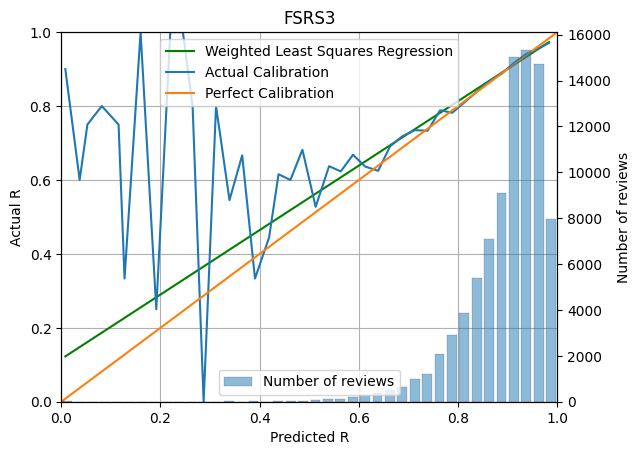


Last rating: 1
R-squared: 0.2785
RMSE: 0.0467
[0.34101897 0.60268102]

Last rating: 2
R-squared: -0.5371
RMSE: 0.0913
[-0.47165052  1.41836235]

Last rating: 3
R-squared: 0.9188
RMSE: 0.0222
[0.06971084 0.93485611]

Last rating: 4
R-squared: -0.1234
RMSE: 0.0342
[0.46544321 0.52534959]


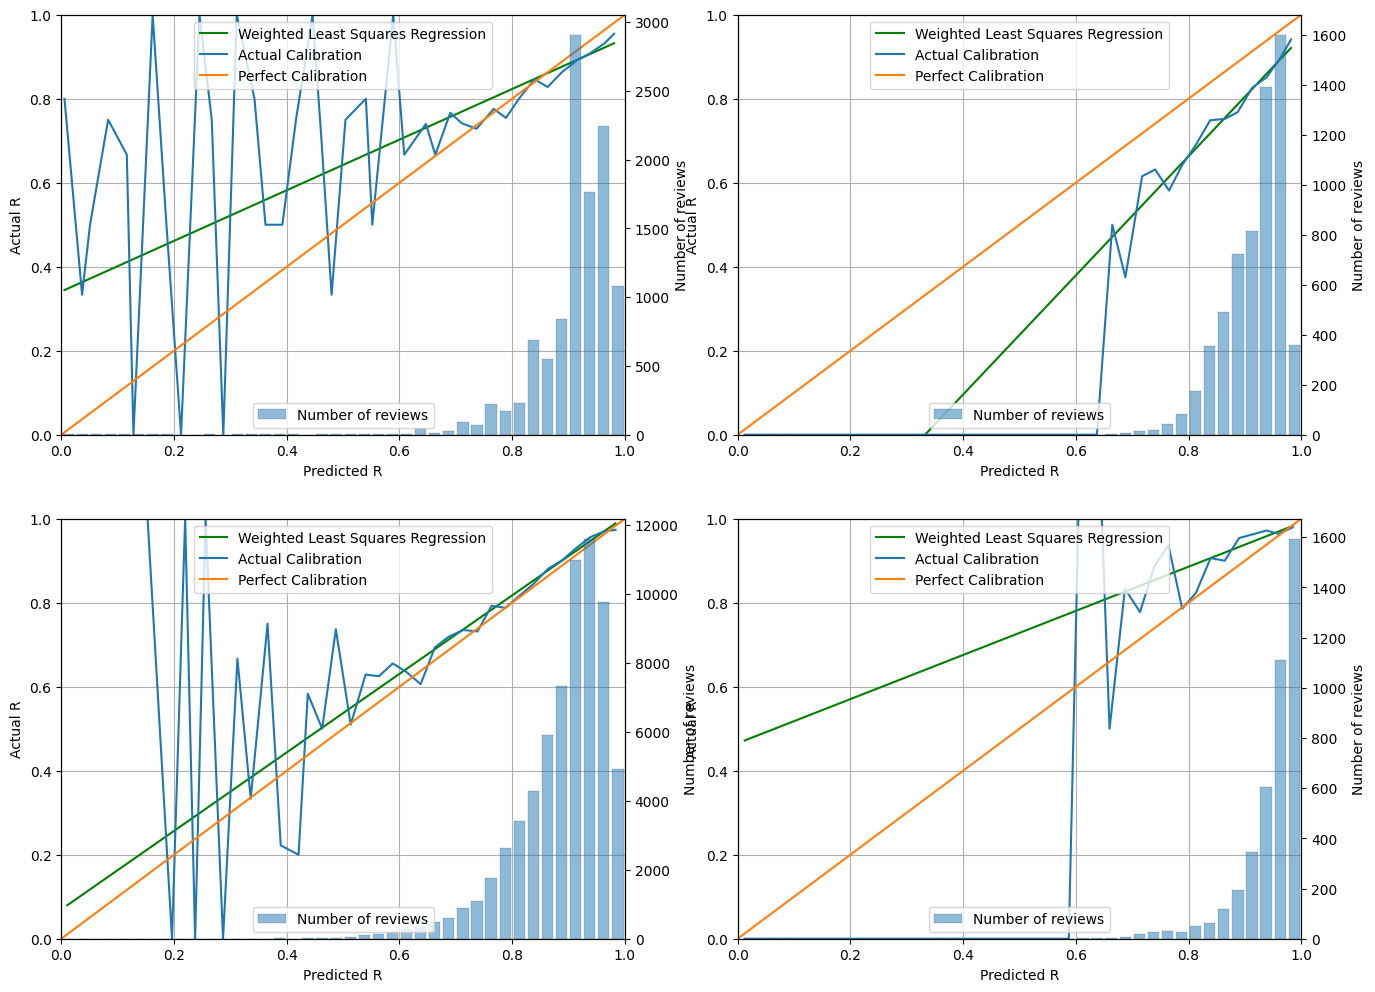

In [7]:
lr: float = 4e-2
n_epoch: int = 5
n_splits: int = 1
batch_size: int = 512
verbose: bool = False

model = FSRS3

dataset = pd.read_csv("./revlog_history.tsv", sep='\t', index_col=None, dtype={'r_history': str ,'t_history': str} )
dataset = dataset[(dataset['i'] > 1) & (dataset['delta_t'] > 0) & (dataset['t_history'].str.count(',0') == 0)]
if dataset.empty:
    raise ValueError('Training data is inadequate.')

if model == RNN:
    dataset['tensor'] = dataset.progress_apply(lambda x: lineToTensorRNN(list(zip([x['t_history']], [x['r_history']]))[0]), axis=1)
else:
    dataset['tensor'] = dataset.progress_apply(lambda x: lineToTensor(list(zip([x['t_history']], [x['r_history']]))[0]), axis=1)
dataset['group'] = dataset['r_history'] + dataset['t_history']
print("Tensorized!")

w = []
plots = []
if n_splits > 1:
    sgkf = StratifiedGroupKFold(n_splits=n_splits)
    for train_index, test_index in sgkf.split(dataset, dataset['i'], dataset['group']):
        print("TRAIN:", len(train_index), "TEST:",  len(test_index))
        train_set = dataset.iloc[train_index].copy()
        test_set = dataset.iloc[test_index].copy()
        trainer = Trainer(model(), train_set, test_set, n_epoch=n_epoch, lr=lr, batch_size=batch_size)
        w.append(trainer.train(verbose=verbose))
        # plots.append(trainer.plot())
else:
    trainer = Trainer(model(), dataset, dataset, n_epoch=n_epoch, lr=lr, batch_size=batch_size)
    w.append(trainer.train(verbose=verbose))
    # plots.append(trainer.plot())

w = np.array(w)
avg_w = np.round(np.mean(w, axis=0), 4)
fsrs3_w = avg_w.tolist()

print("\nTraining finished!")

my_collection = Collection(model())
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])
dataset['log_loss'] = dataset.apply(lambda row: - np.log(row['p']) if row['y'] == 1 else - np.log(1 - row['p']), axis=1)
loss_before = dataset['log_loss'].mean()

my_collection = Collection(model(fsrs3_w))
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])
dataset['log_loss'] = dataset.apply(lambda row: - np.log(row['p']) if row['y'] == 1 else - np.log(1 - row['p']), axis=1)
loss_after = dataset['log_loss'].mean()
print(f"loss before: {loss_before:.4f}, loss after: {loss_after:.4f}, improvement: {loss_before - loss_after:.4f}")

plot_brier(dataset['p'], dataset['y'], bins=40)
plt.title("FSRS3")
plt.show()
plt.figure(figsize=(16, 12))
for last_rating in ("1","2","3","4"):
    plt.subplot(2, 2, int(last_rating))
    print(f"\nLast rating: {last_rating}")
    plot_brier(dataset[dataset['r_history'].str.endswith(last_rating)]['p'], dataset[dataset['r_history'].str.endswith(last_rating)]['y'], bins=40)

  0%|          | 0/88151 [00:00<?, ?it/s]

Tensorized!
dataset built


train:   0%|          | 0/391950 [00:00<?, ?it/s]


Training finished!
loss before: 0.3225, loss after: 0.3042, improvement: 0.0183
R-squared: 0.9626
RMSE: 0.0148
[0.04860534 0.9455223 ]


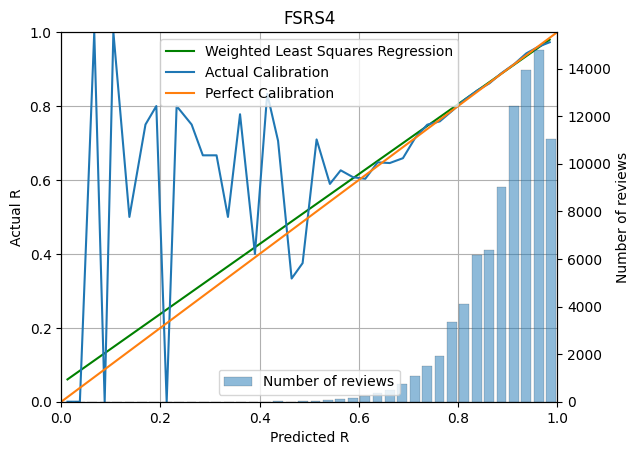


Last rating: 1
R-squared: 0.4177
RMSE: 0.0420
[0.29644007 0.65342603]

Last rating: 2
R-squared: 0.5963
RMSE: 0.0529
[0.04130641 0.90343836]

Last rating: 3
R-squared: 0.9552
RMSE: 0.0169
[0.02219319 0.98269413]

Last rating: 4
R-squared: 0.7681
RMSE: 0.0160
[0.14599725 0.84533459]


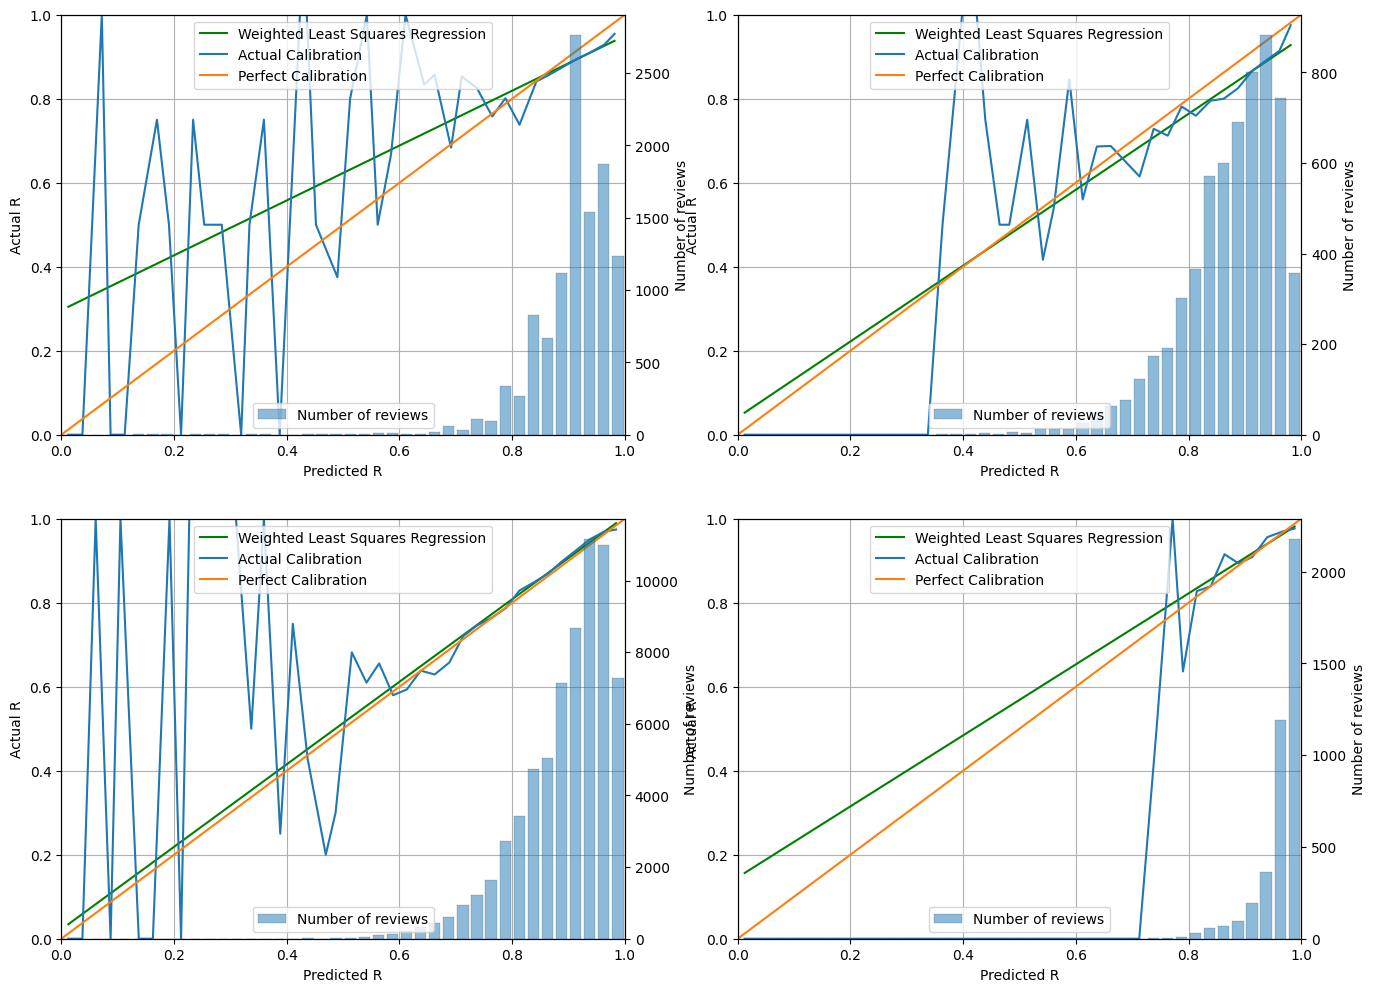

In [8]:
lr: float = 4e-2
n_epoch: int = 5
n_splits: int = 1
batch_size: int = 512
verbose: bool = False

model = FSRS4

dataset = pd.read_csv("./revlog_history.tsv", sep='\t', index_col=None, dtype={'r_history': str ,'t_history': str} )
dataset = dataset[(dataset['i'] > 1) & (dataset['delta_t'] > 0) & (dataset['t_history'].str.count(',0') == 0)]
if dataset.empty:
    raise ValueError('Training data is inadequate.')

if model == RNN:
    dataset['tensor'] = dataset.progress_apply(lambda x: lineToTensorRNN(list(zip([x['t_history']], [x['r_history']]))[0]), axis=1)
else:
    dataset['tensor'] = dataset.progress_apply(lambda x: lineToTensor(list(zip([x['t_history']], [x['r_history']]))[0]), axis=1)
dataset['group'] = dataset['r_history'] + dataset['t_history']
print("Tensorized!")

w = []
plots = []
if n_splits > 1:
    sgkf = StratifiedGroupKFold(n_splits=n_splits)
    for train_index, test_index in sgkf.split(dataset, dataset['i'], dataset['group']):
        print("TRAIN:", len(train_index), "TEST:",  len(test_index))
        train_set = dataset.iloc[train_index].copy()
        test_set = dataset.iloc[test_index].copy()
        trainer = Trainer(model(), train_set, test_set, n_epoch=n_epoch, lr=lr, batch_size=batch_size)
        w.append(trainer.train(verbose=verbose))
        # plots.append(trainer.plot())
else:
    trainer = Trainer(model(), dataset, dataset, n_epoch=n_epoch, lr=lr, batch_size=batch_size)
    w.append(trainer.train(verbose=verbose))
    # plots.append(trainer.plot())


w = np.array(w)
avg_w = np.round(np.mean(w, axis=0), 4)
fsrs4_w = avg_w.tolist()

print("\nTraining finished!")

my_collection = Collection(model())
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])
dataset['log_loss'] = dataset.apply(lambda row: - np.log(row['p']) if row['y'] == 1 else - np.log(1 - row['p']), axis=1)
loss_before = dataset['log_loss'].mean()

my_collection = Collection(model(fsrs4_w))
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])
dataset['log_loss'] = dataset.apply(lambda row: - np.log(row['p']) if row['y'] == 1 else - np.log(1 - row['p']), axis=1)
loss_after = dataset['log_loss'].mean()
print(f"loss before: {loss_before:.4f}, loss after: {loss_after:.4f}, improvement: {loss_before - loss_after:.4f}")

plot_brier(dataset['p'], dataset['y'], bins=40)
plt.title("FSRS4")
plt.show()
plt.figure(figsize=(16, 12))
for last_rating in ("1","2","3","4"):
    plt.subplot(2, 2, int(last_rating))
    print(f"\nLast rating: {last_rating}")
    plot_brier(dataset[dataset['r_history'].str.endswith(last_rating)]['p'], dataset[dataset['r_history'].str.endswith(last_rating)]['y'], bins=40)

Loss: 0.3915
R-squared: -6.8749
RMSE: 0.1527
[0.68927589 0.25115013]


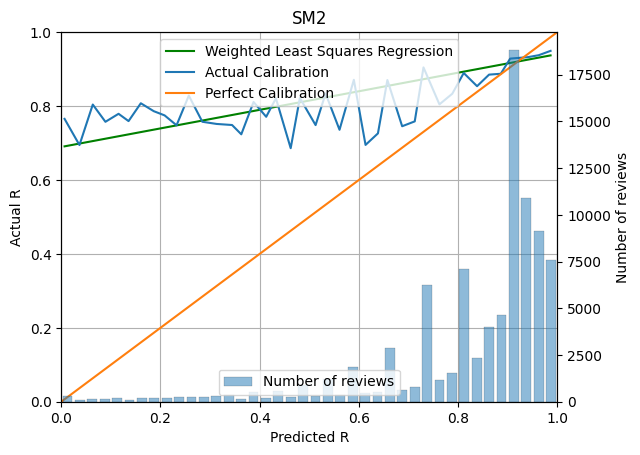


Last rating: 1
R-squared: -11.2415
RMSE: 0.1795
[0.69235888 0.2537902 ]

Last rating: 2
R-squared: -1.3237
RMSE: 0.1064
[0.47013398 0.40360522]

Last rating: 3
R-squared: -5.0796
RMSE: 0.1490
[0.6686561  0.27805895]

Last rating: 4
R-squared: -51.7247
RMSE: 0.2395
[0.9095981  0.06854691]


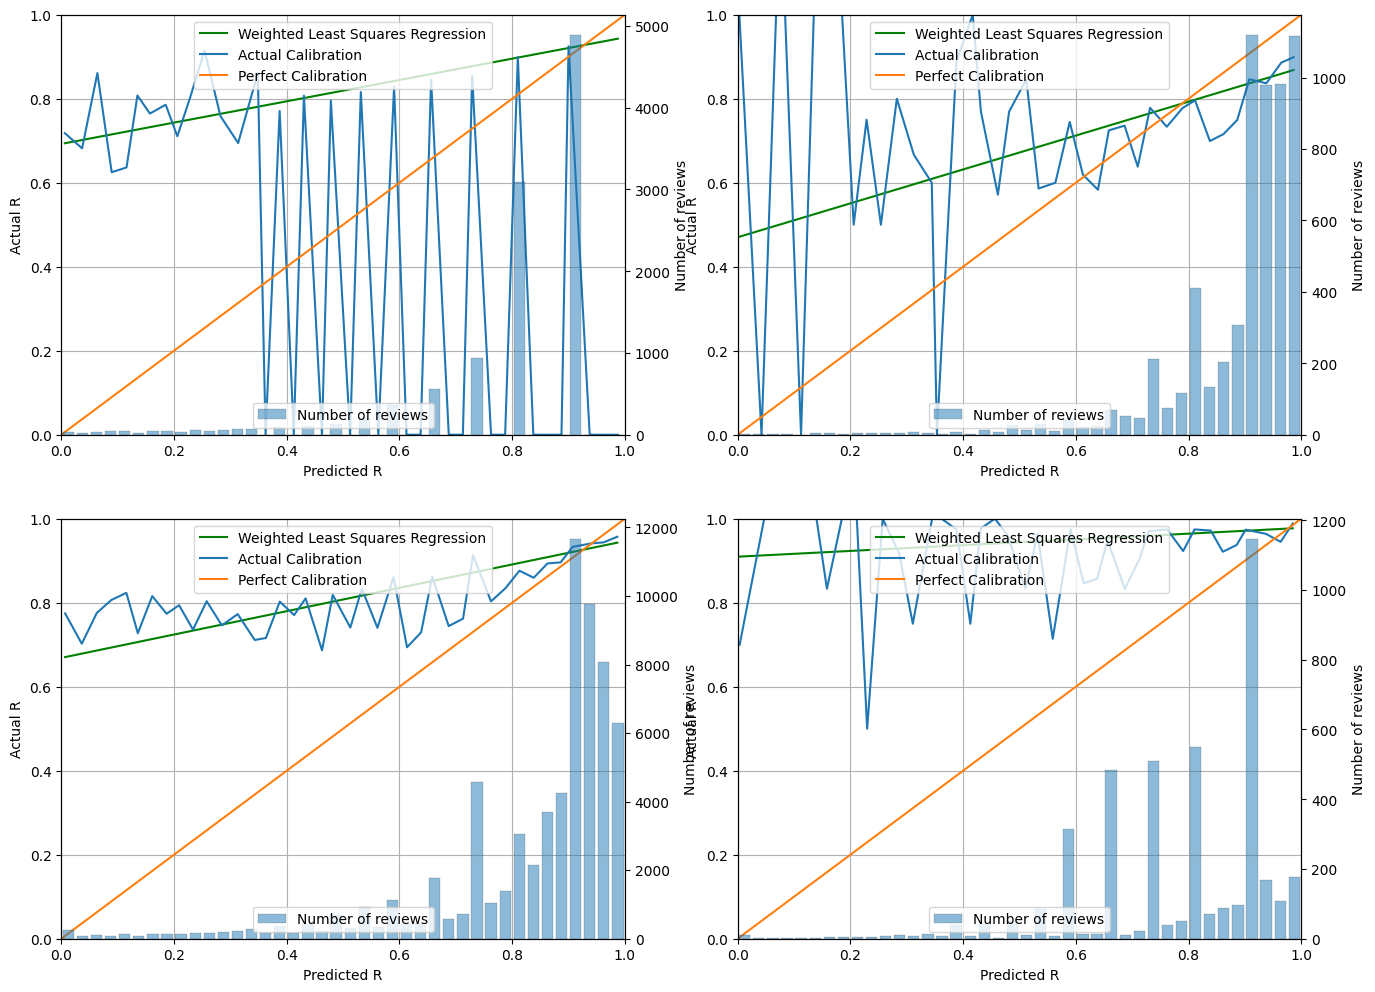

In [9]:
def sm2(history):
    ivl = 0
    ef = 2.5
    reps = 0
    for delta_t, rating in history:
        delta_t = delta_t.item()
        rating = rating.item() + 1
        if rating > 2:
            if reps == 0:
                ivl = 1
                reps = 1
            elif reps == 1:
                ivl = 6
                reps = 2
            else:
                ivl = ivl * ef
                reps += 1
        else:
            ivl = 1
            reps = 0
        ef = max(1.3, ef + (0.1 - (5 - rating) * (0.08 + (5 - rating) * 0.02)))
        ivl = max(1, round(ivl+0.01))
    return ivl


dataset['stability'] = dataset['tensor'].map(sm2)
dataset['p'] = np.exp(np.log(0.9) * dataset['delta_t'] / dataset['stability'])
dataset['log_loss'] = dataset.apply(lambda row: - np.log(row['p']) if row['y'] == 1 else - np.log(1 - row['p']), axis=1)
loss = dataset['log_loss'].mean()
print(f"Loss: {loss:.4f}")

plot_brier(dataset['p'], dataset['y'], bins=40)
plt.title("SM2")
plt.show()
plt.figure(figsize=(16, 12))
for last_rating in ("1","2","3","4"):
    plt.subplot(2, 2, int(last_rating))
    print(f"\nLast rating: {last_rating}")
    plot_brier(dataset[dataset['r_history'].str.endswith(last_rating)]['p'], dataset[dataset['r_history'].str.endswith(last_rating)]['y'], bins=40)

Loss: 0.4474
R-squared: -17.4109
RMSE: 0.1079
[0.87688728 0.02165234]


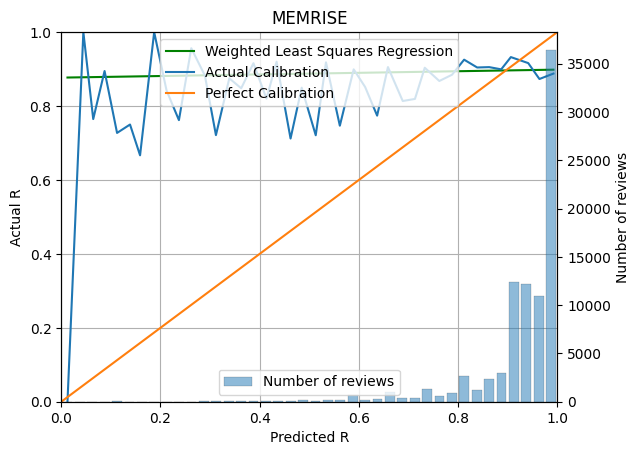


Last rating: 1
R-squared: -16.3025
RMSE: 0.0959
[0.68011388 0.21577034]

Last rating: 2
R-squared: -49.6096
RMSE: 0.1385
[0.80039062 0.03105848]

Last rating: 3
R-squared: -10.6337
RMSE: 0.0991
[0.8126426  0.09455791]

Last rating: 4
R-squared: -53.5531
RMSE: 0.2243
[ 1.02342955 -0.07513608]


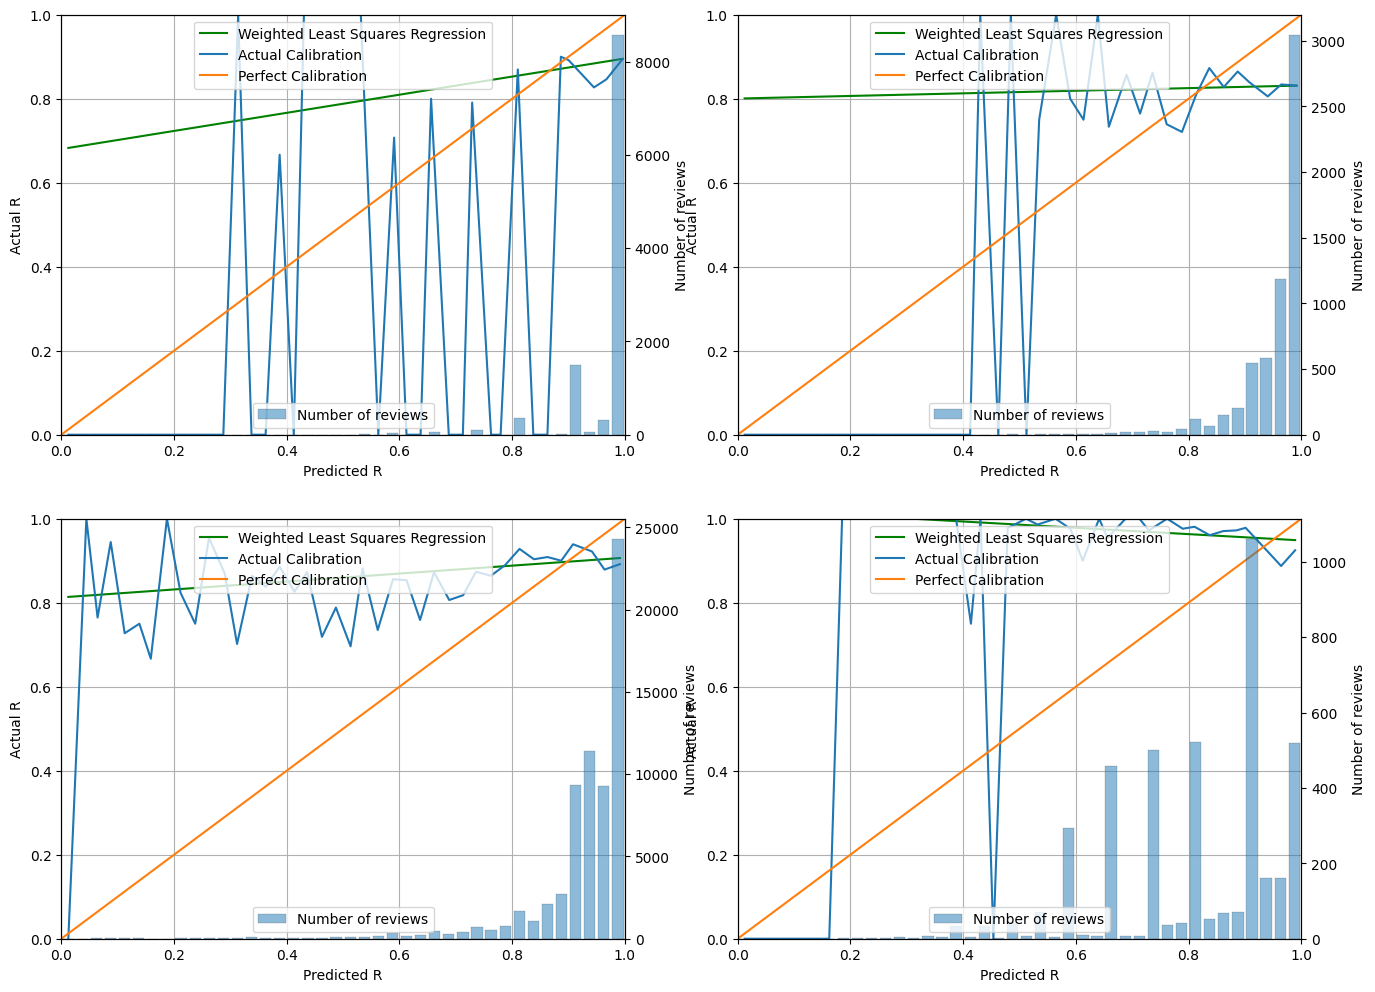

In [10]:
def memrise(history):
    ivl = 0
    reps = 0
    for delta_t, rating in history:
        delta_t = delta_t.item()
        rating = rating.item() + 1
        intervals = [1, 6, 12, 24, 48, 96, 180]
        if rating > 1:
            reps += 1
            if reps > 7:
                reps = 7
            ivl = intervals[reps-1]
        else:
            ivl = 1
            reps = 1
    return ivl

dataset['stability'] = dataset['tensor'].map(memrise)
dataset['p'] = np.exp(np.log(0.9) * dataset['delta_t'] / dataset['stability'])
dataset['log_loss'] = dataset.apply(lambda row: - np.log(row['p']) if row['y'] == 1 else - np.log(1 - row['p']), axis=1)
loss = dataset['log_loss'].mean()
print(f"Loss: {loss:.4f}")
plot_brier(dataset['p'], dataset['y'], bins=40)
plt.title("MEMRISE")
plt.show()
plt.figure(figsize=(16, 12))
for last_rating in ("1","2","3","4"):
    plt.subplot(2, 2, int(last_rating))
    print(f"\nLast rating: {last_rating}")
    plot_brier(dataset[dataset['r_history'].str.endswith(last_rating)]['p'], dataset[dataset['r_history'].str.endswith(last_rating)]['y'], bins=40)

In [11]:
dataset = pd.read_csv("./revlog_history.tsv", sep='\t', index_col=None, dtype={'r_history': str ,'t_history': str} )
dataset = dataset[(dataset['i'] > 1) & (dataset['delta_t'] > 0) & (dataset['t_history'].str.count(',0') == 0)]
dataset['tensor'] = dataset.progress_apply(lambda x: lineToTensor(list(zip([x['t_history']], [x['r_history']]))[0]), axis=1)

my_collection = Collection(FSRS4(fsrs4_w))
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['FSRS4_p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])

my_collection = Collection(FSRS3(fsrs3_w))
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['FSRS3_p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])

dataset['stability'] = dataset['tensor'].map(sm2)
dataset['SM2_p'] = np.exp(np.log(0.9) * dataset['delta_t'] / dataset['stability'])

dataset['stability'] = dataset['tensor'].map(memrise)
dataset['MEMRISE_p'] = np.exp(np.log(0.9) * dataset['delta_t'] / dataset['stability'])

dataset['tensor'] = dataset.progress_apply(lambda x: lineToTensorRNN(list(zip([x['t_history']], [x['r_history']]))[0]), axis=1)

my_collection = Collection(RNN(lstm_w))
stabilities = my_collection.batch_predict(dataset)
dataset['stability'] = stabilities
dataset['LSTM_p'] = my_collection.model.forgetting_curve(dataset['delta_t'], dataset['stability'])

cross_comparison = dataset[['FSRS4_p', 'FSRS3_p', 'LSTM_p', 'SM2_p', 'MEMRISE_p', 'y']].copy()
cross_comparison['FSRS4_bw'] = cross_comparison['FSRS4_p'] - cross_comparison['y']
cross_comparison['FSRS4_bin'] = cross_comparison['FSRS4_p'].map(lambda x: round(x, 1))
cross_comparison['FSRS3_bw'] = cross_comparison['FSRS3_p'] - cross_comparison['y']
cross_comparison['FSRS3_bin'] = cross_comparison['FSRS3_p'].map(lambda x: round(x, 1))
cross_comparison['LSTM_bw'] = cross_comparison['LSTM_p'] - cross_comparison['y']
cross_comparison['LSTM_bin'] = cross_comparison['LSTM_p'].map(lambda x: round(x, 1))
cross_comparison['SM2_bw'] = cross_comparison['SM2_p'] - cross_comparison['y']
cross_comparison['SM2_bin'] = cross_comparison['SM2_p'].map(lambda x: round(x, 1))
cross_comparison['MEMRISE_bw'] = cross_comparison['MEMRISE_p'] - cross_comparison['y']
cross_comparison['MEMRISE_bin'] = cross_comparison['MEMRISE_p'].map(lambda x: round(x, 1))

  0%|          | 0/88151 [00:00<?, ?it/s]

  0%|          | 0/88151 [00:00<?, ?it/s]

Universal Metric of FSRS3: 0.0152
Universal Metric of FSRS4: 0.0134


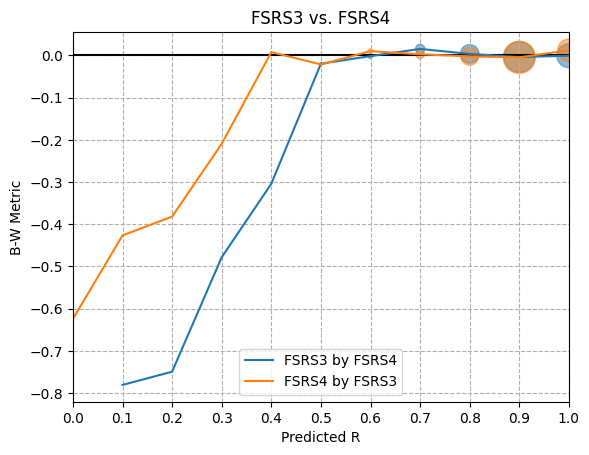

In [12]:
plt.axhline(y = 0.0, color = 'black', linestyle = '-')

classifier = 'FSRS4'
predicter = 'FSRS3'

cross_comparison_group = cross_comparison.groupby(by=f'{classifier}_bin').agg({'y': ['mean'], f'{predicter}_bw': ['mean'], f'{predicter}_p': ['mean', 'count']})
print(f"Universal Metric of {predicter}: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group[f'{predicter}_p', 'mean'], sample_weight=cross_comparison_group[f'{predicter}_p', 'count'], squared=False):.4f}")
cross_comparison_group[f'{classifier}_p', 'percent'] = cross_comparison_group[f'{predicter}_p', 'count'] / cross_comparison_group[f'{predicter}_p', 'count'].sum()
plt.scatter(cross_comparison_group.index, cross_comparison_group[f'{predicter}_bw', 'mean'], s=cross_comparison_group[f'{classifier}_p', 'percent'] * 1024, alpha=0.5)
plt.plot(cross_comparison_group[f'{predicter}_bw', 'mean'], label=f'{predicter} by {classifier}')

cross_comparison_group = cross_comparison.groupby(by=f'{predicter}_bin').agg({'y': ['mean'], f'{classifier}_bw': ['mean'], f'{classifier}_p': ['mean', 'count']})
print(f"Universal Metric of {classifier}: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group[f'{classifier}_p', 'mean'], sample_weight=cross_comparison_group[f'{classifier}_p', 'count'], squared=False):.4f}")
cross_comparison_group[f'{predicter}_p', 'percent'] = cross_comparison_group[f'{classifier}_p', 'count'] / cross_comparison_group[f'{classifier}_p', 'count'].sum()
plt.scatter(cross_comparison_group.index, cross_comparison_group[f'{classifier}_bw', 'mean'], s=cross_comparison_group[f'{predicter}_p', 'percent'] * 1024, alpha=0.5)
plt.plot(cross_comparison_group[f'{classifier}_bw', 'mean'], label=f'{classifier} by {predicter}')

plt.legend(loc='lower center')
plt.grid(linestyle='--')
plt.title(f"{predicter} vs. {classifier}")
plt.xlabel('Predicted R')
plt.ylabel('B-W Metric')
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.show()

Universal Metric of LSTM: 0.0160
Universal Metric of FSRS4: 0.0155


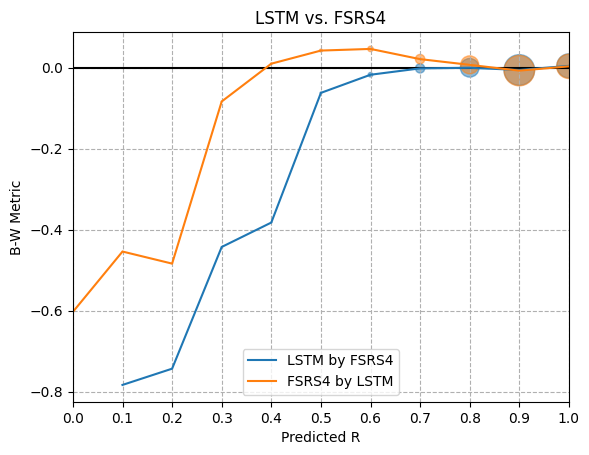

In [13]:
plt.axhline(y = 0.0, color = 'black', linestyle = '-')

classifier = 'FSRS4'
predicter = 'LSTM'

cross_comparison_group = cross_comparison.groupby(by=f'{classifier}_bin').agg({'y': ['mean'], f'{predicter}_bw': ['mean'], f'{predicter}_p': ['mean', 'count']})
print(f"Universal Metric of {predicter}: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group[f'{predicter}_p', 'mean'], sample_weight=cross_comparison_group[f'{predicter}_p', 'count'], squared=False):.4f}")
cross_comparison_group[f'{classifier}_p', 'percent'] = cross_comparison_group[f'{predicter}_p', 'count'] / cross_comparison_group[f'{predicter}_p', 'count'].sum()
plt.scatter(cross_comparison_group.index, cross_comparison_group[f'{predicter}_bw', 'mean'], s=cross_comparison_group[f'{classifier}_p', 'percent'] * 1024, alpha=0.5)
plt.plot(cross_comparison_group[f'{predicter}_bw', 'mean'], label=f'{predicter} by {classifier}')

cross_comparison_group = cross_comparison.groupby(by=f'{predicter}_bin').agg({'y': ['mean'], f'{classifier}_bw': ['mean'], f'{classifier}_p': ['mean', 'count']})
print(f"Universal Metric of {classifier}: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group[f'{classifier}_p', 'mean'], sample_weight=cross_comparison_group[f'{classifier}_p', 'count'], squared=False):.4f}")
cross_comparison_group[f'{predicter}_p', 'percent'] = cross_comparison_group[f'{classifier}_p', 'count'] / cross_comparison_group[f'{classifier}_p', 'count'].sum()
plt.scatter(cross_comparison_group.index, cross_comparison_group[f'{classifier}_bw', 'mean'], s=cross_comparison_group[f'{predicter}_p', 'percent'] * 1024, alpha=0.5)
plt.plot(cross_comparison_group[f'{classifier}_bw', 'mean'], label=f'{classifier} by {predicter}')

plt.legend(loc='lower center')
plt.grid(linestyle='--')
plt.title(f"{predicter} vs. {classifier}")
plt.xlabel('Predicted R')
plt.ylabel('B-W Metric')
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.show()

Universal Metric of SM2: 0.0749
Universal Metric of FSRS4: 0.0065


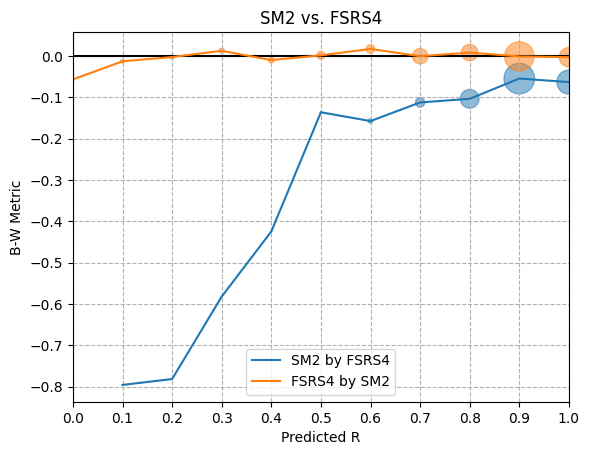

In [14]:
plt.axhline(y = 0.0, color = 'black', linestyle = '-')

classifier = 'FSRS4'
predicter = 'SM2'

cross_comparison_group = cross_comparison.groupby(by=f'{classifier}_bin').agg({'y': ['mean'], f'{predicter}_bw': ['mean'], f'{predicter}_p': ['mean', 'count']})
print(f"Universal Metric of {predicter}: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group[f'{predicter}_p', 'mean'], sample_weight=cross_comparison_group[f'{predicter}_p', 'count'], squared=False):.4f}")
cross_comparison_group[f'{classifier}_p', 'percent'] = cross_comparison_group[f'{predicter}_p', 'count'] / cross_comparison_group[f'{predicter}_p', 'count'].sum()
plt.scatter(cross_comparison_group.index, cross_comparison_group[f'{predicter}_bw', 'mean'], s=cross_comparison_group[f'{classifier}_p', 'percent'] * 1024, alpha=0.5)
plt.plot(cross_comparison_group[f'{predicter}_bw', 'mean'], label=f'{predicter} by {classifier}')

cross_comparison_group = cross_comparison.groupby(by=f'{predicter}_bin').agg({'y': ['mean'], f'{classifier}_bw': ['mean'], f'{classifier}_p': ['mean', 'count']})
print(f"Universal Metric of {classifier}: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group[f'{classifier}_p', 'mean'], sample_weight=cross_comparison_group[f'{classifier}_p', 'count'], squared=False):.4f}")
cross_comparison_group[f'{predicter}_p', 'percent'] = cross_comparison_group[f'{classifier}_p', 'count'] / cross_comparison_group[f'{classifier}_p', 'count'].sum()
plt.scatter(cross_comparison_group.index, cross_comparison_group[f'{classifier}_bw', 'mean'], s=cross_comparison_group[f'{predicter}_p', 'percent'] * 1024, alpha=0.5)
plt.plot(cross_comparison_group[f'{classifier}_bw', 'mean'], label=f'{classifier} by {predicter}')

plt.legend(loc='lower center')
plt.grid(linestyle='--')
plt.title(f"{predicter} vs. {classifier}")
plt.xlabel('Predicted R')
plt.ylabel('B-W Metric')
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.show()

Universal Metric of MEMRISE: 0.0728
Universal Metric of FSRS4: 0.0059


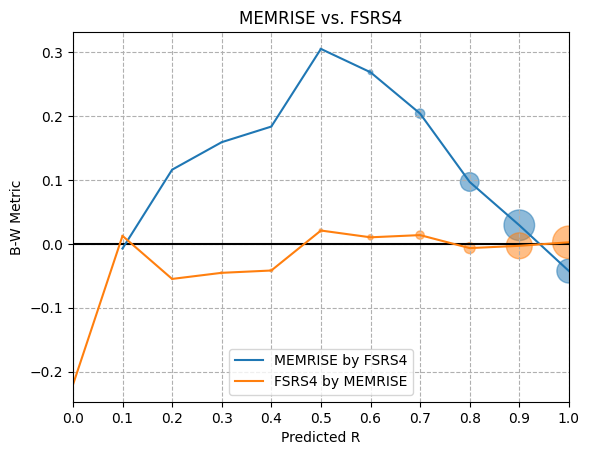

In [15]:
plt.axhline(y = 0.0, color = 'black', linestyle = '-')

classifier = 'FSRS4'
predicter = 'MEMRISE'

cross_comparison_group = cross_comparison.groupby(by=f'{classifier}_bin').agg({'y': ['mean'], f'{predicter}_bw': ['mean'], f'{predicter}_p': ['mean', 'count']})
print(f"Universal Metric of {predicter}: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group[f'{predicter}_p', 'mean'], sample_weight=cross_comparison_group[f'{predicter}_p', 'count'], squared=False):.4f}")
cross_comparison_group[f'{classifier}_p', 'percent'] = cross_comparison_group[f'{predicter}_p', 'count'] / cross_comparison_group[f'{predicter}_p', 'count'].sum()
plt.scatter(cross_comparison_group.index, cross_comparison_group[f'{predicter}_bw', 'mean'], s=cross_comparison_group[f'{classifier}_p', 'percent'] * 1024, alpha=0.5)
plt.plot(cross_comparison_group[f'{predicter}_bw', 'mean'], label=f'{predicter} by {classifier}')

cross_comparison_group = cross_comparison.groupby(by=f'{predicter}_bin').agg({'y': ['mean'], f'{classifier}_bw': ['mean'], f'{classifier}_p': ['mean', 'count']})
print(f"Universal Metric of {classifier}: {mean_squared_error(cross_comparison_group['y', 'mean'], cross_comparison_group[f'{classifier}_p', 'mean'], sample_weight=cross_comparison_group[f'{classifier}_p', 'count'], squared=False):.4f}")
cross_comparison_group[f'{predicter}_p', 'percent'] = cross_comparison_group[f'{classifier}_p', 'count'] / cross_comparison_group[f'{classifier}_p', 'count'].sum()
plt.scatter(cross_comparison_group.index, cross_comparison_group[f'{classifier}_bw', 'mean'], s=cross_comparison_group[f'{predicter}_p', 'percent'] * 1024, alpha=0.5)
plt.plot(cross_comparison_group[f'{classifier}_bw', 'mean'], label=f'{classifier} by {predicter}')

plt.legend(loc='lower center')
plt.grid(linestyle='--')
plt.title(f"{predicter} vs. {classifier}")
plt.xlabel('Predicted R')
plt.ylabel('B-W Metric')
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.show()